# Trabajo Final - Análisis Estadístico
# Parte II – Test de hipótesis y Regresión Lineal

**Variables seleccionadas**

- Variable independiente (X): `Temperatura_Abrigo_150cm`
- Variable dependiente (Y): `Radiacion_Global`

En este notebook se desarrolla paso a paso la Parte II del trabajo práctico.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

# Lectura del archivo
df = pd.read_csv("13_Santa_Fe_Vera.csv", sep=";")
df.columns = df.columns.str.strip()

print("Columnas del archivo:")
print(df.columns.tolist())

x = df["Temperatura_Abrigo_150cm"]
y = df["Radiacion_Global"]

print("\nCantidad de observaciones:", len(df))
df.head()


Columnas del archivo:
['Fecha', 'Temperatura_Abrigo_150cm', 'Humedad_Media', 'Presion_Media', 'Radiacion_Global']

Cantidad de observaciones: 397


,Fecha,Temperatura_Abrigo_150cm,Humedad_Media,Presion_Media,Radiacion_Global
0,2020-11-17 00:00:00.0,22.50138,63,1002.589,20.57220
1,2020-11-18 00:00:00.0,23.20000,70,1002.975,12.68538
2,2020-11-19 00:00:00.0,23.49300,69,1003.864,25.44714
3,2020-11-20 00:00:00.0,24.02708,67,1003.560,26.07630
4,2020-11-21 00:00:00.0,23.85625,62,1003.160,22.22316


## 1. Diagrama de dispersión

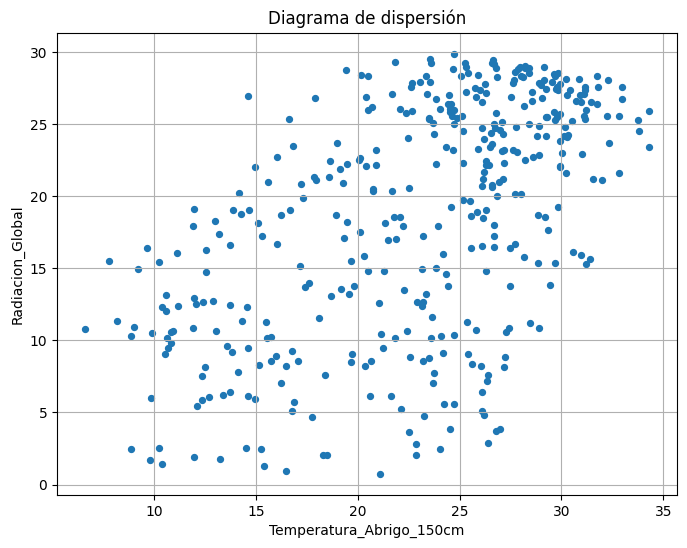

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(x,y,s=18)
plt.xlabel("Temperatura_Abrigo_150cm")
plt.ylabel("Radiacion_Global")
plt.title("Diagrama de dispersión")
plt.grid(True)
plt.show()


## 2. Ajuste del modelo

Se ajusta el modelo

\[
Y=\beta_0+\beta_1X+\varepsilon
\]

utilizando mínimos cuadrados.


In [ ]:
resultado = stats.linregress(x,y)

b1 = resultado.slope
b0 = resultado.intercept

r = resultado.rvalue
R2 = r**2

print("Ordenada al origen =", b0)
print("Pendiente =", b1)
print("Coeficiente de correlación =", r)
print("Coeficiente de determinación =", R2)

y_est = b0 + b1*x


Ordenada al origen = 2.5236889026016165
Pendiente = 0.6962858366135786
Coeficiente de correlación = 0.5479871142554984
Coeficiente de determinación = 0.3002898773900687


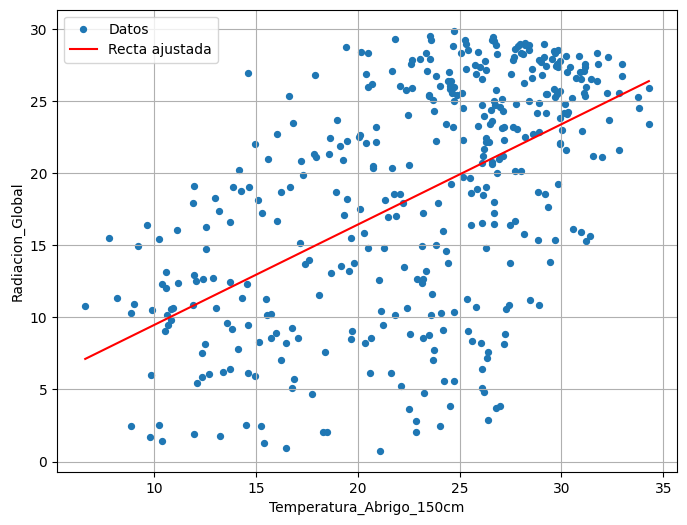

In [ ]:
orden=np.argsort(x)

plt.figure(figsize=(8,6))
plt.scatter(x,y,s=18,label="Datos")
plt.plot(x.iloc[orden],y_est.iloc[orden],color="red",label="Recta ajustada")
plt.xlabel("Temperatura_Abrigo_150cm")
plt.ylabel("Radiacion_Global")
plt.legend()
plt.grid(True)
plt.show()


## 3. Análisis de residuos

count    3.970000e+02
mean    -1.431824e-15
std      6.754719e+00
min     -1.803492e+01
25%     -4.573875e+00
50%      1.226927e+00
75%      5.296628e+00
max      1.425765e+01
dtype: float64


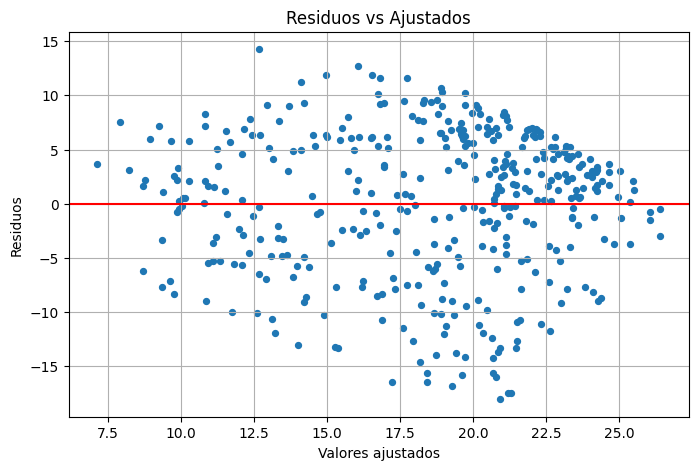

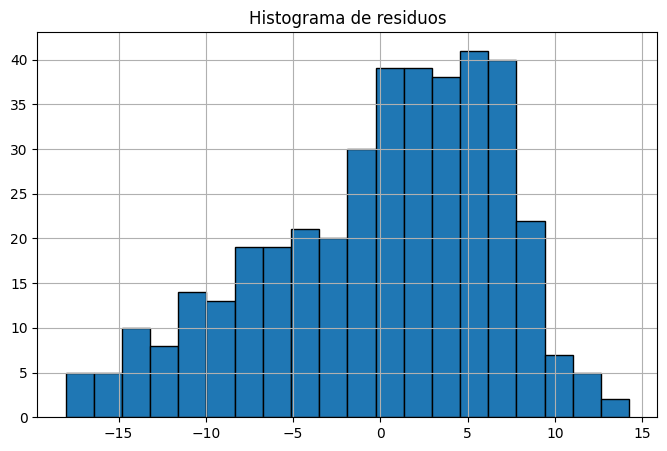

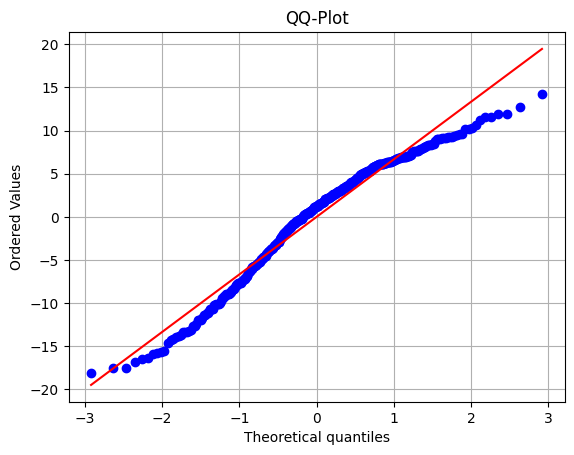

Shapiro-Wilk
W = 0.9623812997116376
p-valor = 1.4761708790877683e-08


In [ ]:
res = y - y_est

print(res.describe())

plt.figure(figsize=(8,5))
plt.scatter(y_est,res,s=18)
plt.axhline(0,color="red")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs Ajustados")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.hist(res,bins=20,edgecolor="black")
plt.title("Histograma de residuos")
plt.grid(True)
plt.show()

stats.probplot(res,dist="norm",plot=plt)
plt.title("QQ-Plot")
plt.grid(True)
plt.show()

W,p = stats.shapiro(res)
print("Shapiro-Wilk")
print("W =",W)
print("p-valor =",p)


## 4. Coeficiente de determinación

El coeficiente de determinación es:

\[
R^2=r^2
\]

e indica la proporción de variabilidad de la variable respuesta explicada por el modelo lineal.


In [ ]:
print("R² =",R2)

R² = 0.3002898773900687


## 5. Test de hipótesis sobre la pendiente

Hipótesis:

\[
H_0: \beta_1 = 0
\]

\[
H_1: \beta_1 \neq 0
\]

Nivel de significación:

\[
\alpha=0.05
\]


In [ ]:
alpha=0.05

t = resultado.slope/resultado.stderr

print("Pendiente =",resultado.slope)
print("Error estándar =",resultado.stderr)
print("Estadístico t =",t)
print("p-valor =",resultado.pvalue)

if resultado.pvalue < alpha:
    print("\nDecisión: Se rechaza H0.")
    print("Conclusión: la pendiente es estadísticamente significativa.")
else:
    print("\nDecisión: No se rechaza H0.")


Pendiente = 0.6962858366135786
Error estándar = 0.053478318745878786
Estadístico t = 13.019964967900878
p-valor = 1.711667556253458e-32

Decisión: Se rechaza H0.
Conclusión: la pendiente es estadísticamente significativa.


## 6. Regresión lineal múltiple (Opcional)

In [ ]:
X = df[["Temperatura_Abrigo_150cm","Humedad_Media","Presion_Media"]]
X = sm.add_constant(X)

modelo = sm.OLS(y,X)
ajuste = modelo.fit()

print(ajuste.summary())


                            OLS Regression Results                            
Dep. Variable:       Radiacion_Global   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     249.1
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           1.59e-90
Time:                        02:18:03   Log-Likelihood:                -1180.6
No. Observations:                 397   AIC:                             2369.
Df Residuals:                     393   BIC:                             2385.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   